# ===================================================
# Notebook 03 : Exploratory Data Analysis
# ===================================================


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

print("Libraries Loaded Successfully ✅")

Libraries Loaded Successfully ✅


In [ ]:
# Load Clean Dataset

df = pd.read_csv(
    "/content/cleaned_hotel_bookings.csv",
    parse_dates=["reservation_status_date"]
)

print(df.shape)

(87396, 34)


In [ ]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_guests,total_nights
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,0.0,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01,2.0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,0.0,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01,2.0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,0.0,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02,1.0,1
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02,1.0,1
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,0.0,0,Transient,98.0,0,1,Check-Out,2015-07-03,2.0,2


In [ ]:
print(df.shape)

(87396, 34)


hotel
City Hotel      53428
Resort Hotel    33968
Name: count, dtype: int64


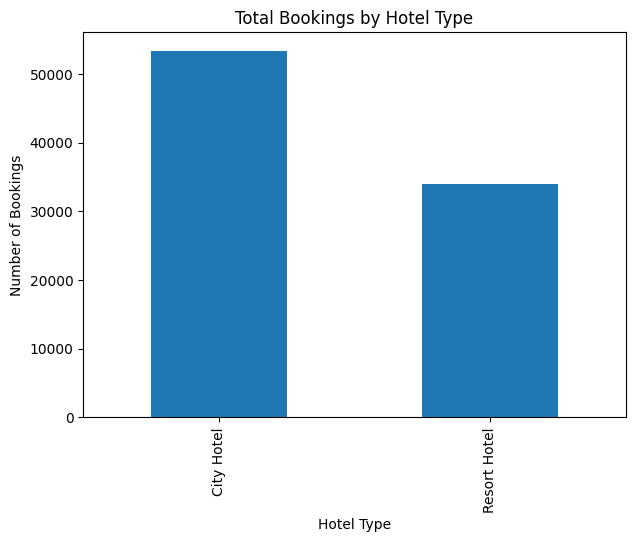

In [ ]:
# ===========================================
# Total Bookings by Hotel Type
# ===========================================

hotel_counts = df["hotel"].value_counts()

print(hotel_counts)

hotel_counts.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Total Bookings by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Number of Bookings")

plt.show()

is_canceled
0    63371
1    24025
Name: count, dtype: int64


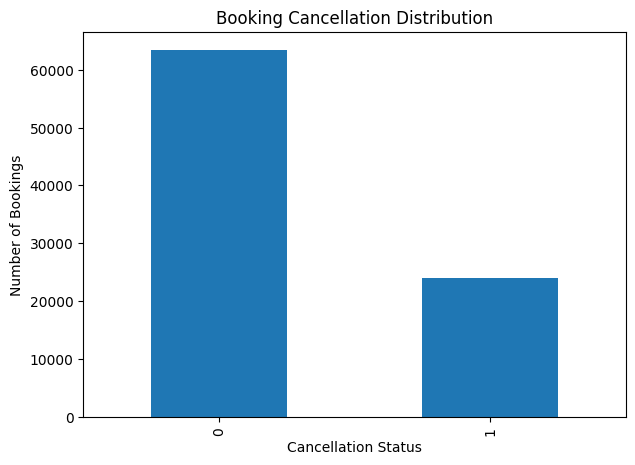

In [ ]:
# ===========================================
# Cancellation Distribution
# ===========================================

cancel = df["is_canceled"].value_counts()

print(cancel)

cancel.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Booking Cancellation Distribution")
plt.xlabel("Cancellation Status")
plt.ylabel("Number of Bookings")

plt.show()

In [ ]:
# Cancellation Percentage

cancel_percent = round(
    df["is_canceled"].value_counts(normalize=True)*100,
    2
)

print(cancel_percent)

is_canceled
0    72.51
1    27.49
Name: proportion, dtype: float64


## Observation

Approximately 27.49_% of bookings were cancelled.

## Business Insight

A high cancellation rate directly impacts hotel occupancy,
pricing strategy and revenue planning.

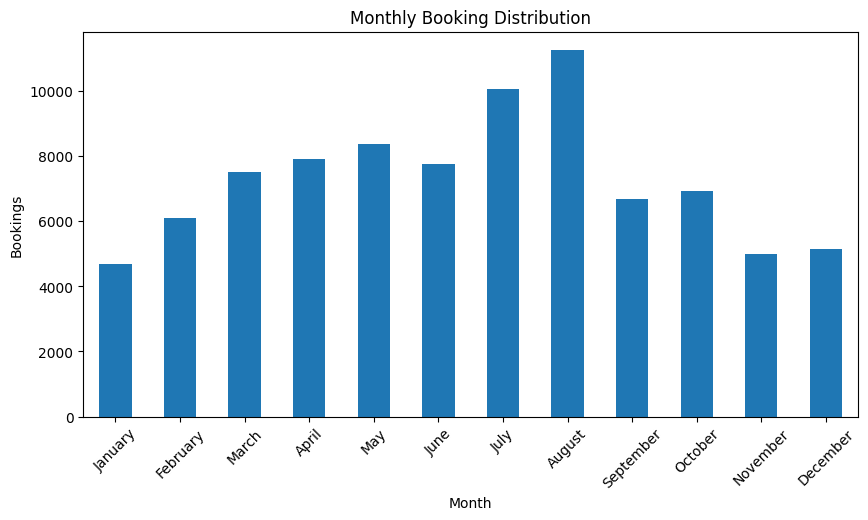

In [ ]:
month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

monthly = df["arrival_date_month"].value_counts()

monthly = monthly.reindex(month_order)

monthly.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Monthly Booking Distribution")
plt.xlabel("Month")
plt.ylabel("Bookings")

plt.xticks(rotation=45)

plt.show()

In [ ]:
hotel_cancel = pd.crosstab(
    df["hotel"],
    df["is_canceled"],
    normalize="index"
)*100

hotel_cancel

is_canceled,0,1
hotel,,
City Hotel,69.961443,30.038557
Resort Hotel,76.519077,23.480923


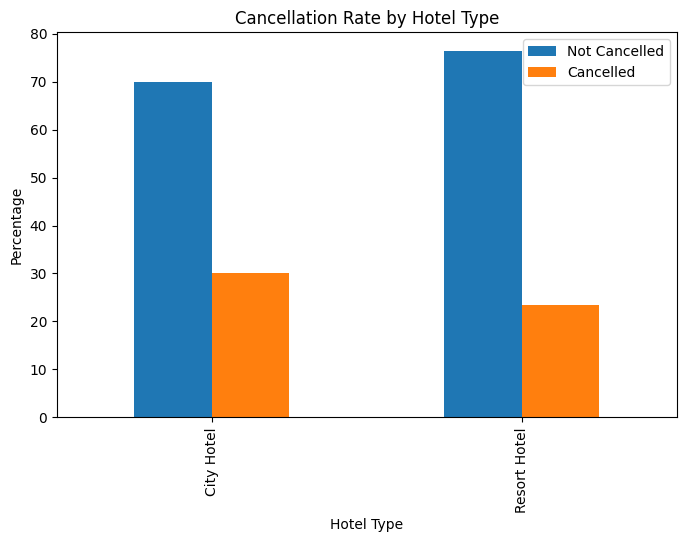

In [ ]:
hotel_cancel.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Cancellation Rate by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Percentage")

plt.legend(["Not Cancelled","Cancelled"])

plt.show()

In [ ]:
hotel_counts

cancel_percent

monthly

hotel_cancel

is_canceled,0,1
hotel,,
City Hotel,69.961443,30.038557
Resort Hotel,76.519077,23.480923


1. City Hotels receive more bookings.

2. Cancellation rate is significantly high.

3. Peak demand is concentrated in specific months.

4. Revenue planning should focus on seasonal trends.

"Observation":-
City Hotels have a cancellation rate of 30.04%.
Resort Hotels have a lower cancellation rate of 23.48%.
Resort Hotels retain a higher percentage of confirmed bookings (76.52%).

Business Insight

City Hotels experience a significantly higher cancellation rate compared to Resort Hotels. This suggests that customers booking city accommodations may have more flexible travel plans or business-related uncertainties. Hotel management can reduce revenue loss by implementing flexible pricing strategies, reminder notifications, or partial deposit policies for City Hotel bookings.

is_canceled
0     70.099588
1    105.719251
Name: lead_time, dtype: float64


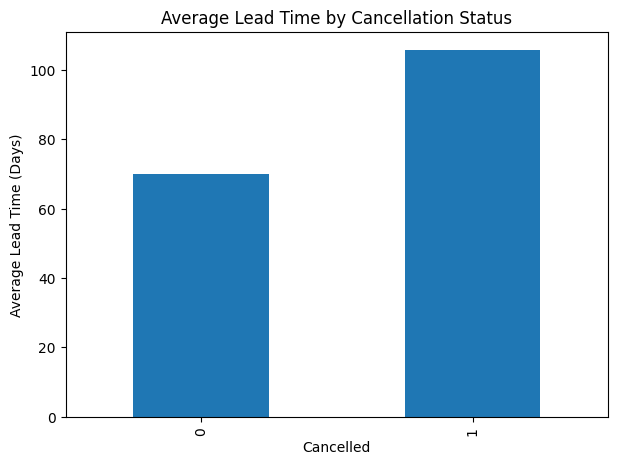

In [ ]:
lead_cancel = df.groupby("is_canceled")["lead_time"].mean()

print(lead_cancel)

lead_cancel.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Average Lead Time by Cancellation Status")
plt.xlabel("Cancelled")
plt.ylabel("Average Lead Time (Days)")

plt.show()

Section 5 : Lead Time Analysis

❓Business Question

Do customers who book earlier have a higher chance of cancellation?

In [ ]:
# ===========================================
# Average Lead Time by Cancellation Status
# ===========================================

lead_cancel = (
    df.groupby("is_canceled")["lead_time"]
    .mean()
    .round(2)
)

print(lead_cancel)

is_canceled
0     70.10
1    105.72
Name: lead_time, dtype: float64


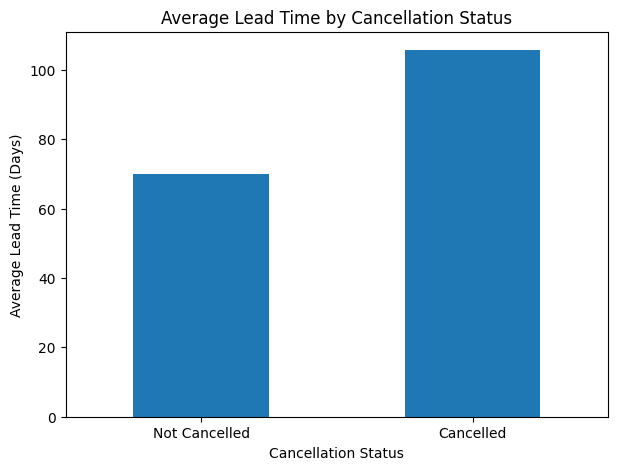

In [ ]:
lead_cancel.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Average Lead Time by Cancellation Status")
plt.xlabel("Cancellation Status")
plt.ylabel("Average Lead Time (Days)")

plt.xticks([0,1],["Not Cancelled","Cancelled"],rotation=0)

plt.show()

## Business Insight

Bookings made far in advance are more likely to be cancelled.
Hotels can reduce cancellation losses by introducing reminder emails,
dynamic pricing or partial payment policies for high lead-time bookings.

In [ ]:
month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

monthly_bookings = (
    df["arrival_date_month"]
    .value_counts()
    .reindex(month_order)
)

print(monthly_bookings)

arrival_date_month
January       4693
February      6098
March         7513
April         7908
May           8355
June          7765
July         10057
August       11257
September     6690
October       6934
November      4995
December      5131
Name: count, dtype: int64


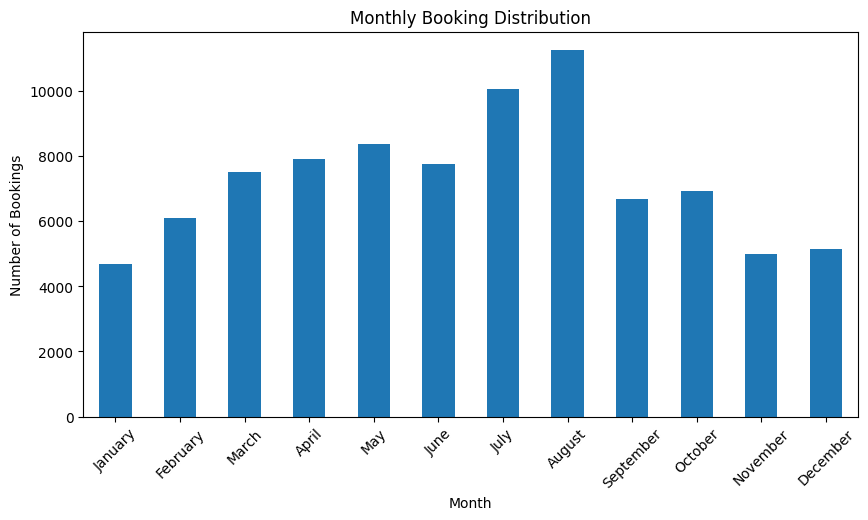

In [ ]:
monthly_bookings.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Monthly Booking Distribution")
plt.xlabel("Month")
plt.ylabel("Number of Bookings")

plt.xticks(rotation=45)

plt.show()

## Business Insight

Hotels should increase staffing and optimize pricing strategies
during peak months while offering promotional discounts
during low-demand periods.

Section 7 : Country-wise Top 10 Bookings
❓Business Question

Which countries contribute the highest number of bookings?

In [ ]:
top_country = (
    df["country"]
    .value_counts()
    .head(10)
)

print(top_country)

country
PRT    27453
GBR    10433
FRA     8837
ESP     7252
DEU     5387
ITA     3066
IRL     3016
BEL     2081
BRA     1995
NLD     1911
Name: count, dtype: int64


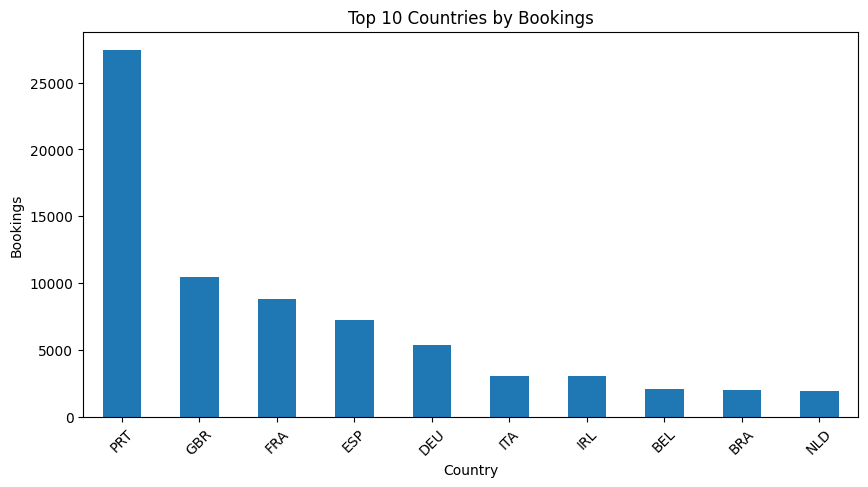

In [ ]:
top_country.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Countries by Bookings")
plt.xlabel("Country")
plt.ylabel("Bookings")

plt.xticks(rotation=45)

plt.show()

In [ ]:
lead_cancel

monthly_bookings

top_country


,count
country,
PRT,27453
GBR,10433
FRA,8837
ESP,7252
DEU,5387
ITA,3066
IRL,3016
BEL,2081
BRA,1995


Markdown

📊 Observation

Portugal contributes the highest number of hotel bookings (27,453), which is more than 2.5 times the bookings from the United Kingdom.
European countries dominate the top 10 booking sources.
Portugal, the UK, France and Spain together account for a major share of total bookings.

💼 Business Insight

Hotels should prioritize marketing campaigns, loyalty programs and personalized offers for customers from Portugal and other high-contributing European countries. Since these markets generate the majority of bookings, improving customer retention here can have a significant impact on occupancy and revenue.

Question

Does Deposit Type affect Cancellation?

In [ ]:
deposit_cancel = pd.crosstab(
    df["deposit_type"],
    df["is_canceled"],
    normalize="index"
) * 100

deposit_cancel.round(2)

is_canceled,0,1
deposit_type,,
No Deposit,73.32,26.68
Non Refund,5.30,94.70
Refundable,75.70,24.30


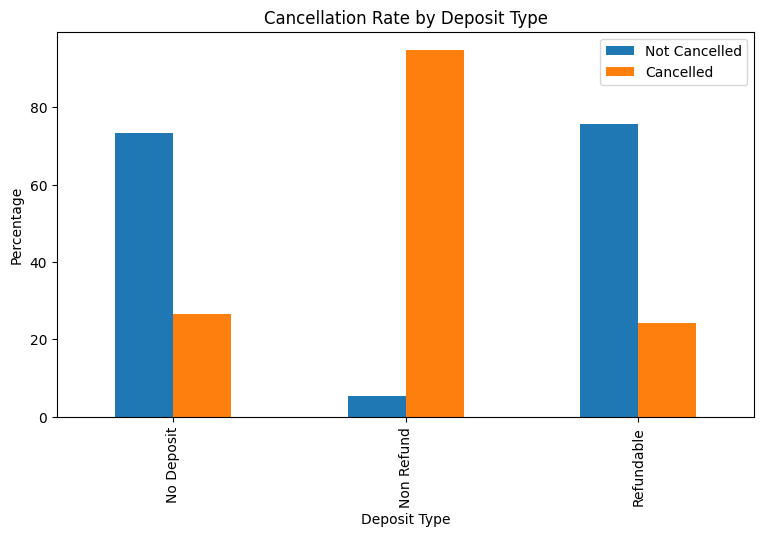

In [ ]:
deposit_cancel.plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Cancellation Rate by Deposit Type")
plt.xlabel("Deposit Type")
plt.ylabel("Percentage")

plt.legend(["Not Cancelled","Cancelled"])

plt.show()

Markdown

📊 Observation

Bookings with Non Refund deposits show an exceptionally high cancellation rate (94.70%).
Both No Deposit and Refundable bookings have cancellation rates around 25-27%.

💼 Business Insight

The relationship between deposit policy and cancellations is not straightforward. The unusually high cancellation rate for Non Refund bookings suggests that these bookings may belong to specific customer segments or business scenarios. Further analysis by market segment and customer type is recommended before making pricing or policy decisions.

is_canceled
0     70.10
1    105.72
Name: lead_time, dtype: float64


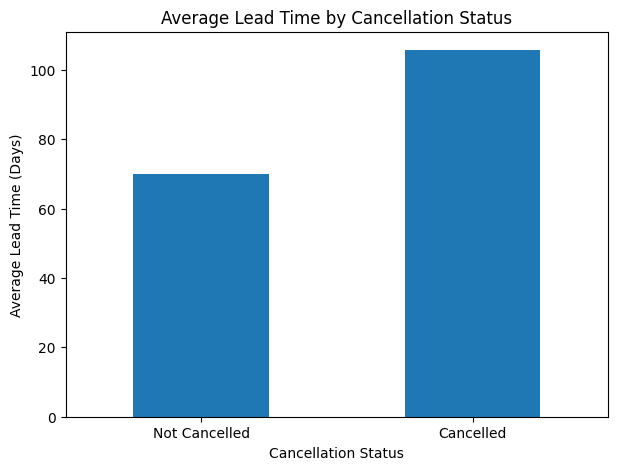

In [ ]:
lead_time_analysis = (
    df.groupby("is_canceled")["lead_time"]
    .mean()
    .round(2)
)

print(lead_time_analysis)

lead_time_analysis.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Average Lead Time by Cancellation Status")
plt.xlabel("Cancellation Status")
plt.ylabel("Average Lead Time (Days)")

plt.xticks([0,1],["Not Cancelled","Cancelled"],rotation=0)

plt.show()

Section 9 : Market Segment Analysis

market_segment
Online TA        51618
Offline TA/TO    13889
Direct           11804
Groups            4942
Corporate         4212
Complementary      702
Aviation           227
Undefined            2
Name: count, dtype: int64


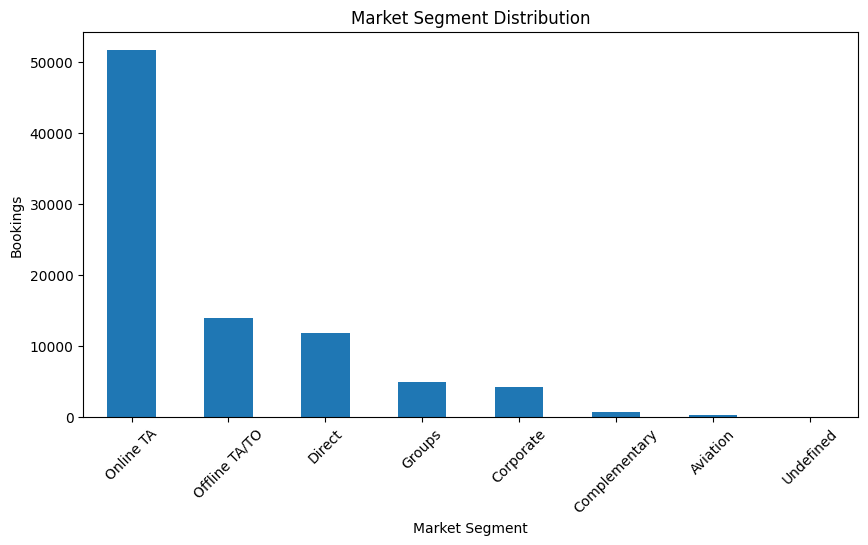

In [ ]:
market = df["market_segment"].value_counts()

print(market)

market.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Market Segment Distribution")
plt.xlabel("Market Segment")
plt.ylabel("Bookings")

plt.xticks(rotation=45)

plt.show()

Observation

Online TA dominates bookings.

Business Insight

Hotels rely heavily on Online Travel Agencies, making partnerships and commission optimization important.

Section 10 : ADR Distribution

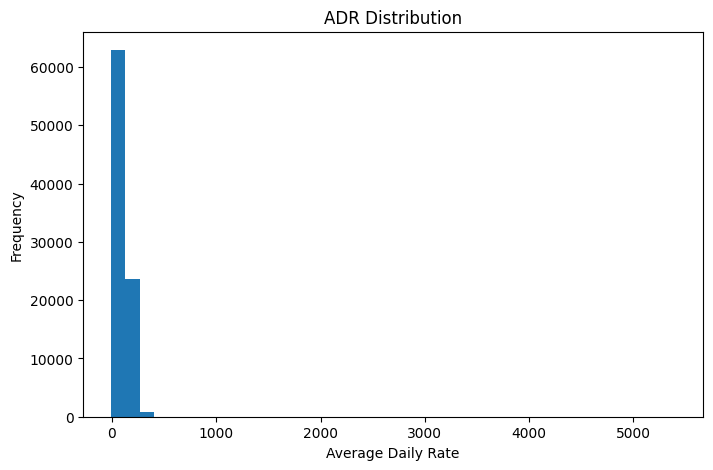

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df["adr"], bins=40)

plt.title("ADR Distribution")

plt.xlabel("Average Daily Rate")

plt.ylabel("Frequency")

plt.show()

Observation

Most bookings fall under a moderate ADR range with a few expensive outliers.

Business Insight

Hotels can optimize dynamic pricing while identifying premium pricing opportunities.

Section 11 : Special Requests

total_of_special_requests
0    33.202716
1    22.411000
2    21.291907
3    17.134225
4    10.625000
5     5.555556
Name: is_canceled, dtype: float64


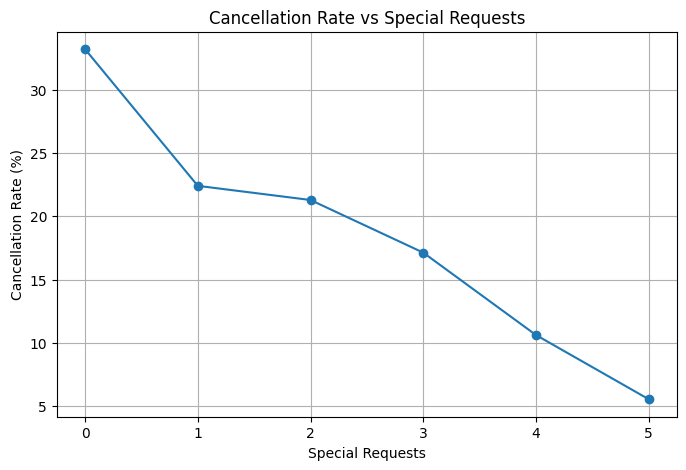

In [ ]:
special = df.groupby(
    "total_of_special_requests"
)["is_canceled"].mean()*100

print(special)

special.plot(
    kind="line",
    marker="o",
    figsize=(8,5)
)

plt.title("Cancellation Rate vs Special Requests")

plt.xlabel("Special Requests")

plt.ylabel("Cancellation Rate (%)")

plt.grid()

plt.show()

Observation

Customers making more special requests generally cancel less.

Business Insight

Highly engaged customers are more likely to complete their stay.

Section 12 : Repeated Guest Analysis

In [ ]:
repeat = pd.crosstab(

    df["is_repeated_guest"],

    df["is_canceled"],

    normalize="index"

)*100

repeat.round(2)

is_canceled,0,1
is_repeated_guest,,
0,71.70,28.30
1,92.36,7.64


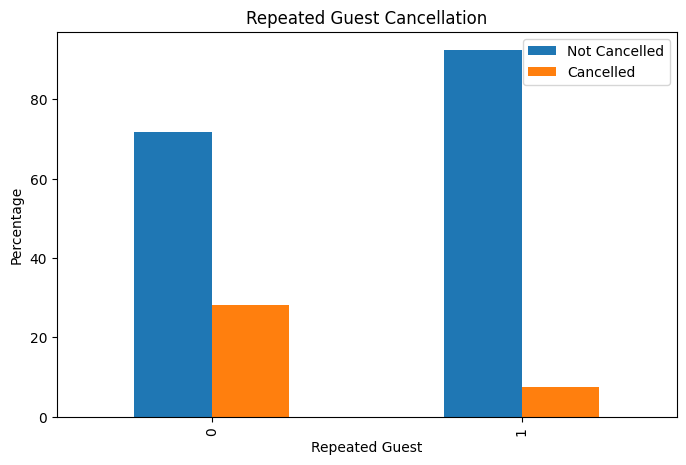

In [ ]:
repeat.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Repeated Guest Cancellation")

plt.xlabel("Repeated Guest")

plt.ylabel("Percentage")

plt.legend(["Not Cancelled","Cancelled"])

plt.show()

Observation

Repeated guests have significantly lower cancellation rates.

Business Insight

Customer retention strategies directly improve occupancy and revenue stability.

Section 13 : Average ADR by Hotel

hotel
City Hotel      110.99
Resort Hotel     99.03
Name: adr, dtype: float64


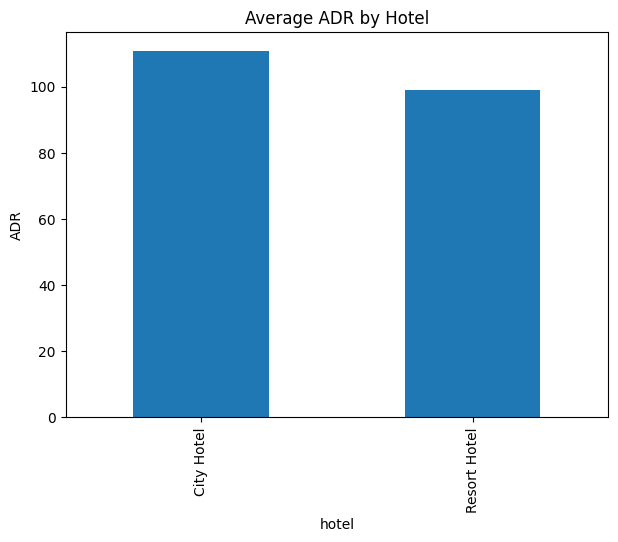

In [ ]:
adr = df.groupby("hotel")["adr"].mean().round(2)

print(adr)

adr.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Average ADR by Hotel")

plt.ylabel("ADR")

plt.show()

Section 14 : Total Nights Distribution

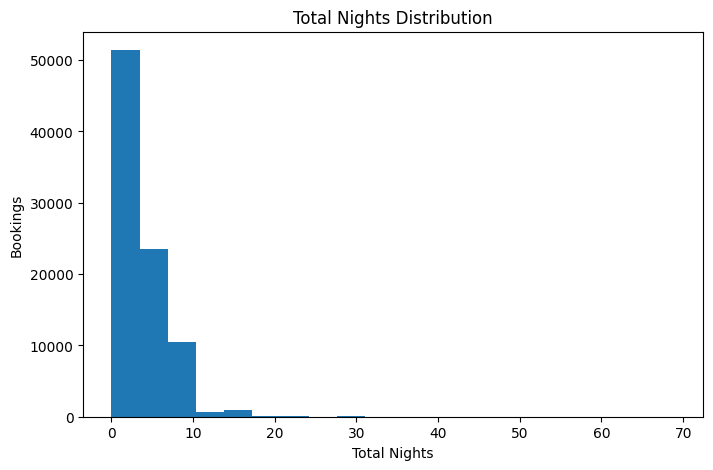

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df["total_nights"], bins=20)

plt.title("Total Nights Distribution")

plt.xlabel("Total Nights")

plt.ylabel("Bookings")

plt.show()

1. Resort Hotels have lower cancellation rates than City Hotels.

2. Portugal contributes the highest number of bookings.

3. Non Refund bookings show an unexpectedly high cancellation rate (94.70%), indicating the need for deeper customer segmentation analysis.

4. Deposit policy alone cannot explain cancellation behaviour.

1. City Hotels receive more bookings but also experience higher cancellation rates.

2. Portugal contributes the largest share of hotel bookings.

3. Most customers book through Online Travel Agencies.

4. Repeated guests are much less likely to cancel their bookings.

5. Customers with more special requests tend to complete their stays.

6. Peak booking months indicate strong seasonality.

7. Deposit type alone does not fully explain cancellation behaviour.

8. Most bookings are made by transient customers.

9. The majority of bookings fall within a moderate ADR range.

10. Hotel managers can reduce revenue loss by focusing on customer retention and personalized engagement strategies.